ΜΕΡΟΣ Δ

Εργασια Μιχαηλ Μπαλτζακη : 10989 Αγγελου Γουργαρη : 11164

In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import seaborn as sns
from sklearn.manifold import TSNE

###Φόρτωση των αρχεiων datasetTest.csv και datasetTV.csv και μετατροπή σε pandas dataframe

In [4]:
cols = list(range(0, 224))
cols_str = [str(col) for col in cols]
prefix = 'feature'
my_cols_test = [(prefix+col) for col in cols_str]
my_cols = my_cols_test.copy()
my_cols.append('Label')

training_df = pd.read_csv('data/datasetTV.csv', header=None, names=my_cols)
test_df =  pd.read_csv('data/datasetTest.csv', header=None, names=my_cols_test)

###Συναρτήσεις αξιολόγησης του μοντέλου μας και tuning του μοντέλου

In [5]:

def evaluate(y_true, y_pred, class_names=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    unique_classes = np.unique(y_true)
    num_classes = len(unique_classes)

    print("Accuracy:",  round(accuracy_score(y_true, y_pred)*100, 2), "%")
    print("Precision:", round(precision_score(y_true, y_pred, average="macro")*100, 2), "%")
    print("Recall:",    round(recall_score(y_true, y_pred, average="macro")*100, 2), "%")
    print("F1 Score:",  round(f1_score(y_true,    y_pred, average="macro")*100,  2), "%")

    print("\nMulticlass problem detected – showing confusion matrix...")
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    plt.title("Confusion Matrix")
    plt.show()

def tune_model(model, param_grid, X_train, y_train, X_test, y_test, return_model=False):
  # Ορίζουμε το GridSearchCV()
  grid_search = GridSearchCV(model,
                             param_grid,
                             cv=5,
                             n_jobs=-1,
                             verbose=2
                             )

  # Το μοντέλο μας θα τρέξει K=5 φορές για κάθε πιθανό συνδιασμό υπερπαραμέτρων
  grid_search.fit(X_train, y_train)

  # Όταν τελειώσει η διαδικασία μπορούμε να ανακτήσουμε τον συνδυασμό υπερ-παραμέτρουν που δίνουν την καλύτερη απόδοση βάσει το cross validation process
  print(f"Best parameters: {grid_search.best_params_}")

  # Μπορούμε να ανακτήσουμε το μοντέλο με την καλύτερη απόδοση (βάσει του Cross Validation)

  best_model = grid_search.best_estimator_

  # Και μετά να κάνουμε αξιολόγηση στο τελικό testing set
  y_pred = best_model.predict(X_test)
  class_names = np.unique(y_test)
  evaluate(y_test, y_pred, class_names)

  if return_model:
    return best_model

###Απλό ιστόγραμμα των δεδομένων για να δούμε αν οι κλάσεις μας είναι ισορροπημένες

<Axes: xlabel='Label'>

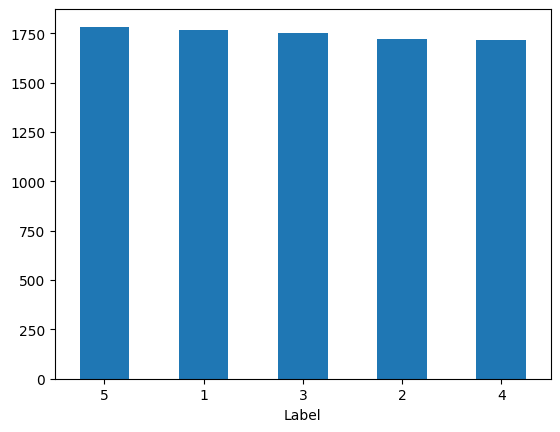

In [6]:
X = training_df.drop(columns=['Label']).to_numpy()
y = training_df['Label'].to_numpy()

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Εχω ισορροπημενα δεδομενα
pd.Series(training_df['Label']).value_counts().plot(kind='bar', rot=0)

###Πρώτη αξιολόγηση για να δούμε ποιο μοντέλο θα χρησιμοποιήσουμε

Ο boosting είναι πολύ αργόσ γι αυτό τον έχω κάνει comment out στη περίπτωση που θέλει ο αναγνώστης να τρέξει τον κώδικα

Ξεκινάει η αξιολόγηση των μοντέλων...

✅ Gaussian Naive Bayes: 0.6987 (took 0.04s)
✅ Logistic Regression: 0.7799 (took 2.74s)
✅ K-Nearest Neighbors: 0.8468 (took 0.50s)
✅ Decision Tree: 0.6204 (took 5.15s)
✅ Random Forest: 0.8062 (took 23.23s)
✅ AdaBoost: 0.6204 (took 18.49s)
✅ SVC (SVM): 0.8565 (took 4.91s)
✅ MLP Classifier: 0.8416 (took 11.93s)

--- Τελική Κατάταξη Μοντέλων ---
                  Model  Accuracy  Time (sec)
6             SVC (SVM)  0.856489    4.908381
2   K-Nearest Neighbors  0.846770    0.498257
7        MLP Classifier  0.841624   11.929331
4         Random Forest  0.806175   23.232250
1   Logistic Regression  0.779874    2.739949
0  Gaussian Naive Bayes  0.698685    0.040082
3         Decision Tree  0.620354    5.154343
5              AdaBoost  0.620354   18.487138


/tmp/ipykernel_754/3837372455.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=df_results, palette='viridis')


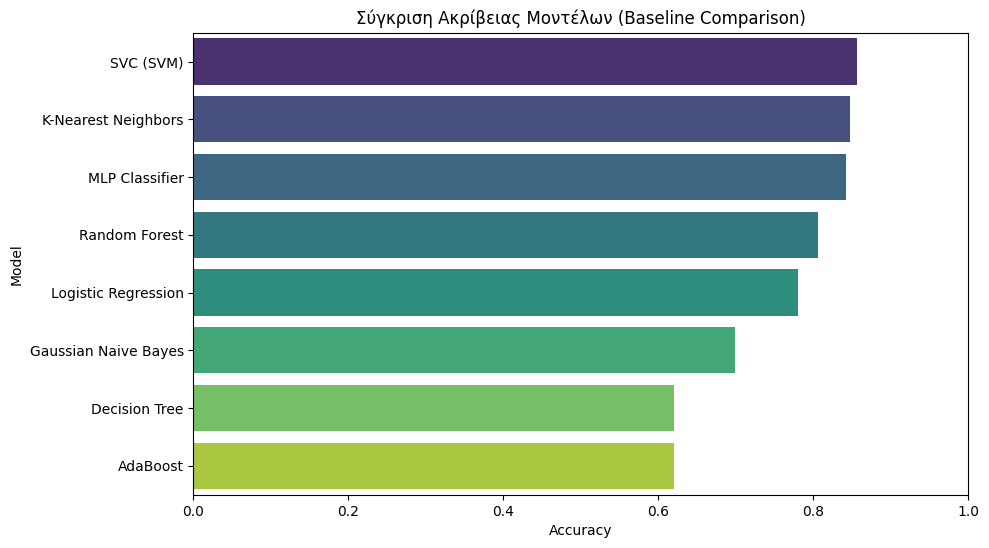

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
import time
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline

# Λίστα με τα μοντέλα (από το πιο απλό στο πιο σύνθετο)
models = [
    # Πιθανοτικά / Στατιστικά
    ('Gaussian Naive Bayes', GaussianNB()),

    # Γραμμικά
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),

    # Instance-based (Βασισμένα στην απόσταση)
    ('K-Nearest Neighbors', KNeighborsClassifier()), # Default k=5

    # Δέντρα Απόφασης
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),

    # Ensembles (Συνδυασμός δέντρων)
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('AdaBoost', AdaBoostClassifier(random_state=42)),
    #('Gradient Boosting', GradientBoostingClassifier(random_state=42)), # ειναι αργος

    #  Kernel-based
    ('SVC (SVM)', SVC(random_state=42)), # Default kernel='rbf'

    # Νευρωνικά Δίκτυα
    ('MLP Classifier', MLPClassifier(max_iter=1000, random_state=42))
]

results = []

print("Ξεκινάει η αξιολόγηση των μοντέλων...\n")

for name, mod in models:
    start_time = time.time()

    model = make_pipeline(None, mod)

    # Εκπαίδευση
    model.fit(X_train, y_train)

    # Πρόβλεψη
    y_pred = model.predict(X_test)

    # Υπολογισμός Ακρίβειας
    acc = accuracy_score(y_test, y_pred)

    end_time = time.time()
    duration = end_time - start_time

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Time (sec)': duration
    })

    print(f"✅ {name}: {acc:.4f} (took {duration:.2f}s)")

# Δημιουργία DataFrame και Ταξινόμηση
df_results = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)

print("\n--- Τελική Κατάταξη Μοντέλων ---")
print(df_results)

# Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=df_results, palette='viridis')
plt.title('Σύγκριση Ακρίβειας Μοντέλων (Baseline Comparison)')
plt.xlim(0, 1.0)  # Για να φαίνεται η κλίμακα μέχρι το 100%
plt.xlabel('Accuracy')
plt.show()

###Επίδραση του scaling

✅ No Scaler (Raw Data): Accuracy = 0.8696 (Time: 6.35s)

✅ MinMax Scaler: Accuracy = 0.8651 (Time: 5.84s)

✅ Standard Scaler: Accuracy = 0.8616 (Time: 7.43s)



/tmp/ipykernel_754/3202328072.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(x='Scaling Method', y='Accuracy', data=df_res, palette='viridis')


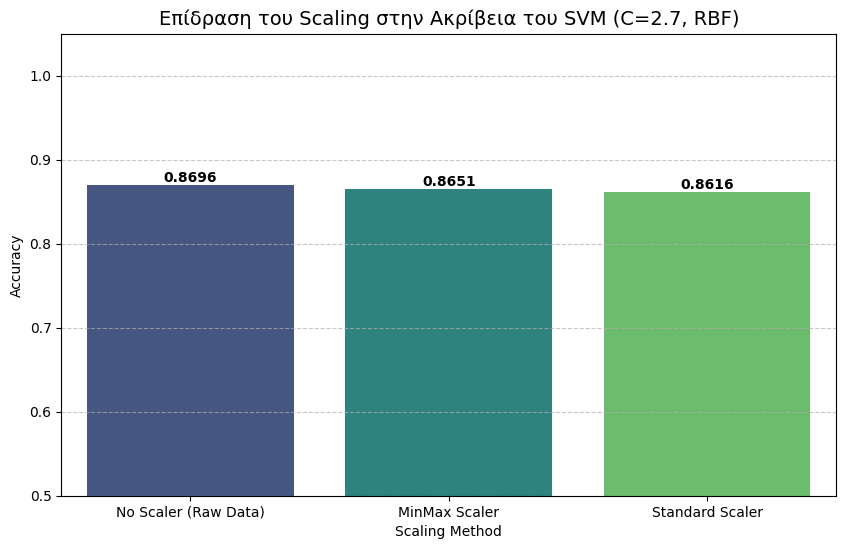

         Scaling Method  Accuracy      Time
0  No Scaler (Raw Data)  0.869640  6.353614
1         MinMax Scaler  0.865066  5.835020
2       Standard Scaler  0.861635  7.429409


In [8]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import make_pipeline
import time

# 1. Ορίζουμε τις 3 περιπτώσεις (λίστα από tuples)
experiments = [
    ('No Scaler (Raw Data)', None),        # Χωρίς κλιμάκωση
    ('MinMax Scaler', MinMaxScaler()),     # Κλιμάκωση στο [0, 1]
    ('Standard Scaler', StandardScaler())  # Κλιμάκωση με z-score (mean=0, std=1)
]

results = []

for name, scaler in experiments:

    # Χρονομέτρηση
    start = time.time()

    # Δημιουργία Pipeline (αν υπάρχει scaler τον βάζουμε, αλλιώς σκέτο το μοντέλο)
    if scaler:
        model = make_pipeline(scaler, SVC(C=2.7, gamma='scale', kernel='rbf', random_state=42))
    else:
        model = SVC(C=2.7, gamma='scale', kernel='rbf', random_state=42)

    # Εκπαίδευση & Πρόβλεψη
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))

    end = time.time()

    # Αποθήκευση αποτελέσματος
    results.append({'Scaling Method': name, 'Accuracy': acc, 'Time': end - start})
    print(f"✅ {name}: Accuracy = {acc:.4f} (Time: {end - start:.2f}s)\n")

# --- Δημιουργία Διαγράμματος ---
df_res = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
# Χρησιμοποιούμε barplot
bar_plot = sns.barplot(x='Scaling Method', y='Accuracy', data=df_res, palette='viridis')

# Βάζουμε τα νούμερα πάνω στις μπάρες για να φαίνονται
for index, row in df_res.iterrows():
    bar_plot.text(index, row.Accuracy, f'{row.Accuracy:.4f}', color='black', ha="center", va="bottom", weight='bold')

plt.title('Επίδραση του Scaling στην Ακρίβεια του SVM (C=2.7, RBF)', fontsize=14)
plt.ylim(0.5, 1.05) # Εστιάζουμε στο πάνω μέρος (50% - 100%) για να φανεί η διαφορά
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(df_res)

###Μοντελο επιλογης και confusion matrix

Accuracy: 86.96 %
Precision: 86.81 %
Recall: 86.79 %
F1 Score: 86.78 %

Multiclass problem detected – showing confusion matrix...


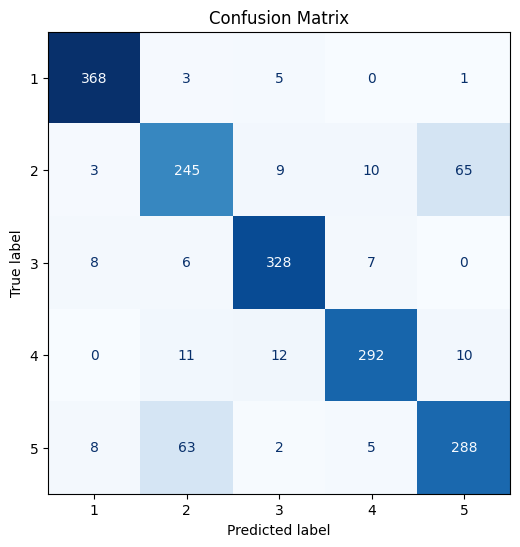

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

#model =
#grid_param = {
#    'C' : [2.7],
#    'gamma' : ['scale'],
#    'kernel': ['rbf']
#}
#best_model = tune_model(model, grid_param, X_train, y_train, X_test, y_test)

# Τελικο μοντελο μετα απο tuning
model =SVC(C=2.7, gamma='scale', kernel='rbf', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluate(y_test, y_pred, np.unique(y))

# Εφαρμογη στο datasetTest
X_final_test = test_df.to_numpy()
labelsX = model.predict(X_final_test)


###t-sne για οπτικοποιηση των κλασεων 2 και 5 στις 2 διαστασεις

Τρέχει το t-SNE...


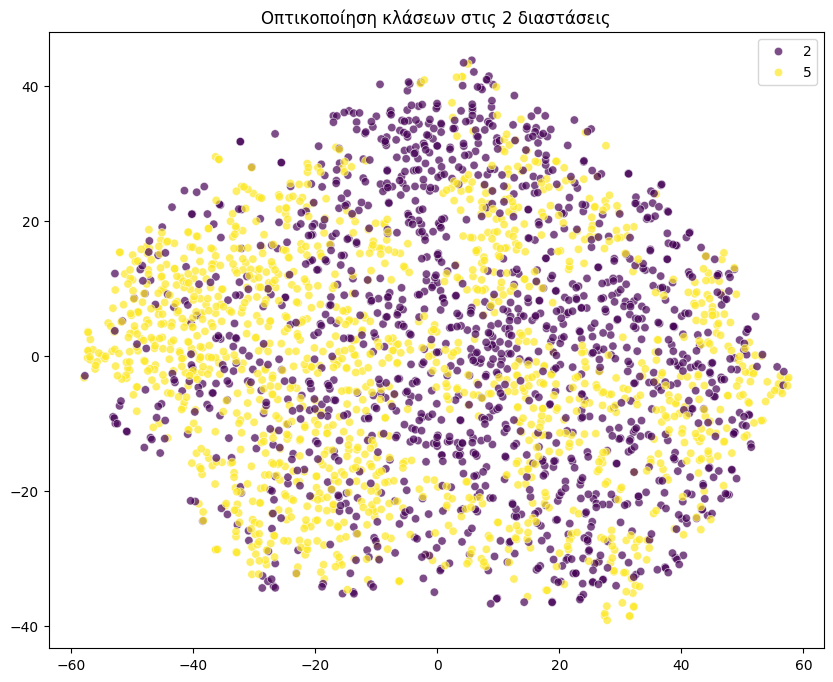

In [11]:
# Πάρε μόνο τα δεδομένα για τις κλάσεις 2 και 5
mask = (y_train == 2) | (y_train == 5)
X_subset = X_train[mask]
y_subset = y_train[mask]

# Τρέξε t-SNE (μείωση σε 2 διαστάσεις)
print("Τρέχει το t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_embedded = tsne.fit_transform(X_subset)

# PLOT
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=y_subset, palette='viridis', alpha=0.7)
plt.title("Οπτικοποίηση κλάσεων στις 2 διαστάσεις")
plt.show()

###Top features για την ταξινόμηση των κλάσεων 2 και 5

--- ΤΑ 5 ΚΑΛΥΤΕΡΑ FEATURES ΓΙΑ ΔΙΑΧΩΡΙΣΜΟ 2 VS 5 ---
     feature_index  cohens_d  mean_diff
67              67  0.577664   0.295414
100            100  0.548614   0.298923
21              21  0.541983   0.292094
175            175  0.483129   0.261592
147            147  0.473596   0.261581


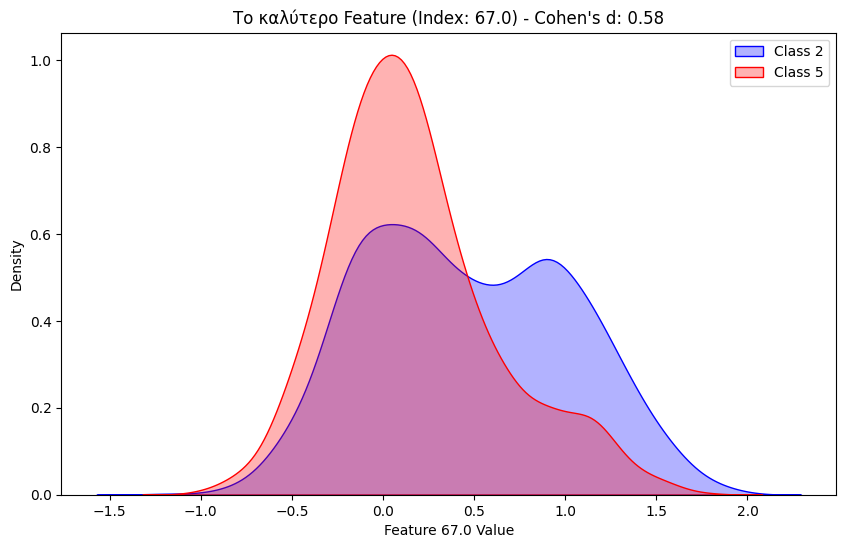

In [12]:
# Απομόνωση των δεδομένων 2 και 5
mask = (y_train == 2) | (y_train == 5)
X_subset = X_train[mask]
y_subset = y_train[mask]

# Μετατροπή σε DataFrame για ευκολία
df = pd.DataFrame(X_subset)
df['label'] = y_subset

# Υπολογισμός Cohen's d για ΚΑΘΕ feature
results = []

features = df.columns.drop('label')

for col in features:
    # Παίρνω τις τιμές για την κλάση 2 και την κλάση 5
    group2 = df[df['label'] == 2][col]
    group5 = df[df['label'] == 5][col]

    # Μέσοι όροι και τυπικές αποκλίσεις
    mean2, mean5 = group2.mean(), group5.mean()
    std2, std5 = group2.std(), group5.std()

    # Υπολογίζω Pooled Standard Deviation
    n2, n5 = len(group2), len(group5)
    pooled_std = np.sqrt(((n2 - 1) * std2**2 + (n5 - 1) * std5**2) / (n2 + n5 - 2))

    # Cohen's d
    d = abs(mean2 - mean5) / pooled_std

    results.append({'feature_index': col, 'cohens_d': d, 'mean_diff': abs(mean2 - mean5)})

# Βρίσκω τα top 5
results_df = pd.DataFrame(results).sort_values(by='cohens_d', ascending=False)
# Τωρα εχουμε και ταξινομημενη λιστα
results= results_df.to_dict(orient='records')

print("--- ΤΑ 5 ΚΑΛΥΤΕΡΑ FEATURES ΓΙΑ ΔΙΑΧΩΡΙΣΜΟ 2 VS 5 ---")
print(results_df.head(5))

# Ζωγραφίζω το ΑΠΟΛΥΤΩΣ ΚΑΛΥΤΕΡΟ feature
best_feature = results_df.iloc[0]['feature_index']
best_d = results_df.iloc[0]['cohens_d']

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['label']==2][best_feature], fill=True, label='Class 2', color='blue', alpha=0.3)
sns.kdeplot(data=df[df['label']==5][best_feature], fill=True, label='Class 5', color='red', alpha=0.3)
plt.title(f'Το καλύτερο Feature (Index: {best_feature}) - Cohen\'s d: {best_d:.2f}')
plt.xlabel(f'Feature {best_feature} Value')
plt.legend()
plt.show()

###Επίδραση της επιλογής του αριθμού των top feature που θα χρησιμοποιήσουμε στην ακρίβεια

Έλεγχος βέλτιστου αριθμού features...
Top 5 Features (Lowest d = 0.474) -> Accuracy: 0.6461
Top 10 Features (Lowest d = 0.432) -> Accuracy: 0.6705
Top 20 Features (Lowest d = 0.365) -> Accuracy: 0.7135
Top 30 Features (Lowest d = 0.305) -> Accuracy: 0.7292
Top 50 Features (Lowest d = 0.234) -> Accuracy: 0.7292
Top 100 Features (Lowest d = 0.115) -> Accuracy: 0.7579
Top 150 Features (Lowest d = 0.043) -> Accuracy: 0.7693
Top 200 Features (Lowest d = 0.015) -> Accuracy: 0.7980
Top 224 Features (Lowest d = 0.000) -> Accuracy: 0.8009


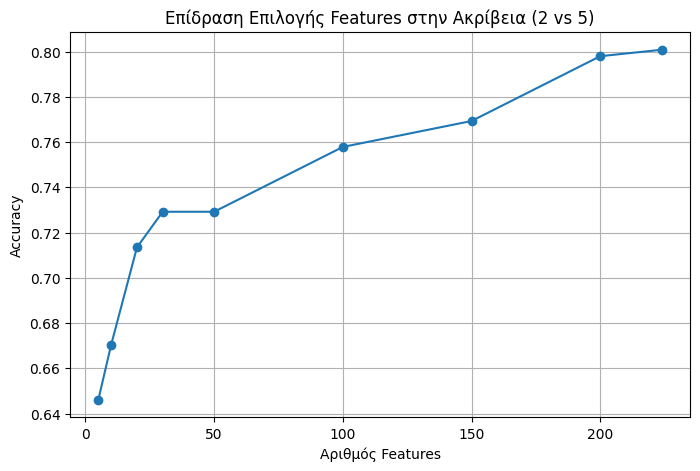

In [13]:
# 1. Παίρνουμε όλα τα features ταξινομημένα με βάση το Cohen's d
# (Υποθέτω ότι η λίστα features_d που έφτιαξες πριν υπάρχει ακόμα)
# features_d = [(index, d_value), (index, d_value), ...]

# 2. Δοκιμάζουμε διαφορετικά πλήθη features (Top-5, Top-10, Top-20, etc.)
num_features_to_test = [5, 10, 20, 30, 50, 100, 150, 200, 224]
accuracies = []

# Φτιάχνουμε μάσκες για το 2 vs 5 (γιατί εκεί εστιάζουμε το feature selection)
mask_train = (y_train == 2) | (y_train == 5)
mask_test = (y_test == 2) | (y_test == 5)
y_train_25 = y_train[mask_train]
y_test_25 = y_test[mask_test]

print("Έλεγχος βέλτιστου αριθμού features...")

for k in num_features_to_test:
    # Διαλέγουμε τα top k features
    top_k_indices = [f['feature_index'] for f in results[:k]]

    # Κόβουμε τα δεδομένα
    X_train_k = X_train[:, top_k_indices][mask_train]
    X_test_k = X_test[:, top_k_indices][mask_test]

    # Εκπαίδευση
    clf = SVC(C=2.7, gamma='scale', kernel='rbf', random_state=42)
    clf.fit(X_train_k, y_train_25)

    # Αξιολόγηση
    acc = accuracy_score(y_test_25, clf.predict(X_test_k))
    accuracies.append(acc)
    print(f"Top {k} Features (Lowest d = {results[k-1]['cohens_d']:.3f}) -> Accuracy: {acc:.4f}")

# 3. Ζωγραφίζουμε το αποτέλεσμα
plt.figure(figsize=(8, 5))
plt.plot(num_features_to_test, accuracies, marker='o')
plt.title("Επίδραση Επιλογής Features στην Ακρίβεια (2 vs 5)")
plt.xlabel("Αριθμός Features")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()